In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
#import the data from drive
cc_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Practice_Dataset_and_files/creditcard.csv')
#The data set is given in the datasets folder, the file name is creditcard.csv. You can download
#and use it for running this model on your system. You just need to change the path in the above
#code with your desired path
cc_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
cc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
cc_df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
cc_df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
#shape of the dataset
print(cc_df.shape)

(284807, 31)


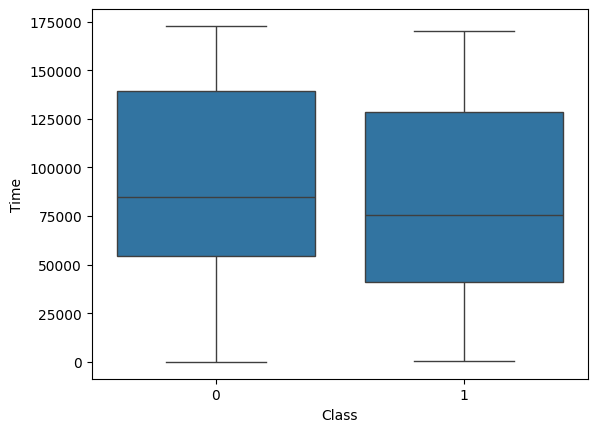

In [ ]:
#box and whisker plot of time taken vs fraud
sns.boxplot(x="Class", y='Time', data=cc_df)
plt.show()

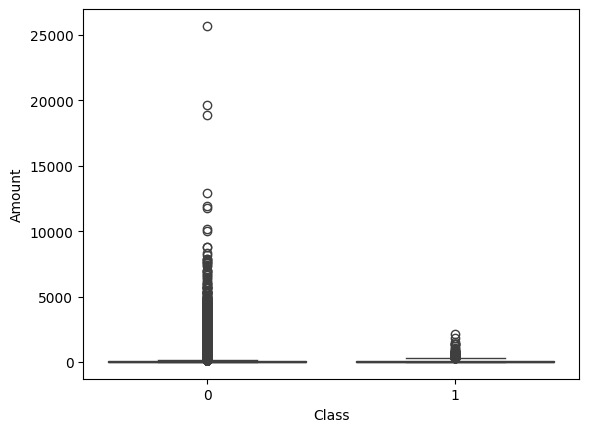

In [ ]:
#box and whisker plot of amount vs fraud
sns.boxplot(x="Class", y='Amount', data=cc_df)
plt.show()

In [ ]:

#isolation for timing
df_fraud = cc_df[cc_df['Class']==1]['Time']
df_no_fraud = cc_df[cc_df['Class']==0]['Time']
print(df_fraud)
print(df_no_fraud)

541          406.0
623          472.0
4920        4462.0
6108        6986.0
6329        7519.0
            ...   
279863    169142.0
280143    169347.0
280149    169351.0
281144    169966.0
281674    170348.0
Name: Time, Length: 492, dtype: float64
0              0.0
1              0.0
2              1.0
3              1.0
4              2.0
            ...   
284802    172786.0
284803    172787.0
284804    172788.0
284805    172788.0
284806    172792.0
Name: Time, Length: 284315, dtype: float64


In [ ]:
#Is the timing of both cases statistically different? Perform T test for time
from scipy import stats
t_value, p_value = stats.ttest_ind(df_fraud, df_no_fraud)
print(t_value, round(p_value,2))


-6.576701136533918 0.0


In [ ]:
#lets do the same analysis for amount

df_fraud_amt = cc_df[cc_df['Class']==1]['Amount']
df_no_fraud_amt = cc_df[cc_df['Class']==0]['Amount']
print(df_fraud_amt)
print(df_no_fraud_amt)

#Is the amount of both cases statistically different? Perform T test for amount
from scipy import stats
t_value, p_value = stats.ttest_ind(df_fraud_amt, df_no_fraud_amt)
print(t_value, round(p_value,2))

541         0.00
623       529.00
4920      239.93
6108       59.00
6329        1.00
           ...  
279863    390.00
280143      0.76
280149     77.89
281144    245.00
281674     42.53
Name: Amount, Length: 492, dtype: float64
0         149.62
1           2.69
2         378.66
3         123.50
4          69.99
           ...  
284802      0.77
284803     24.79
284804     67.88
284805     10.00
284806    217.00
Name: Amount, Length: 284315, dtype: float64
3.00555231397141 0.0


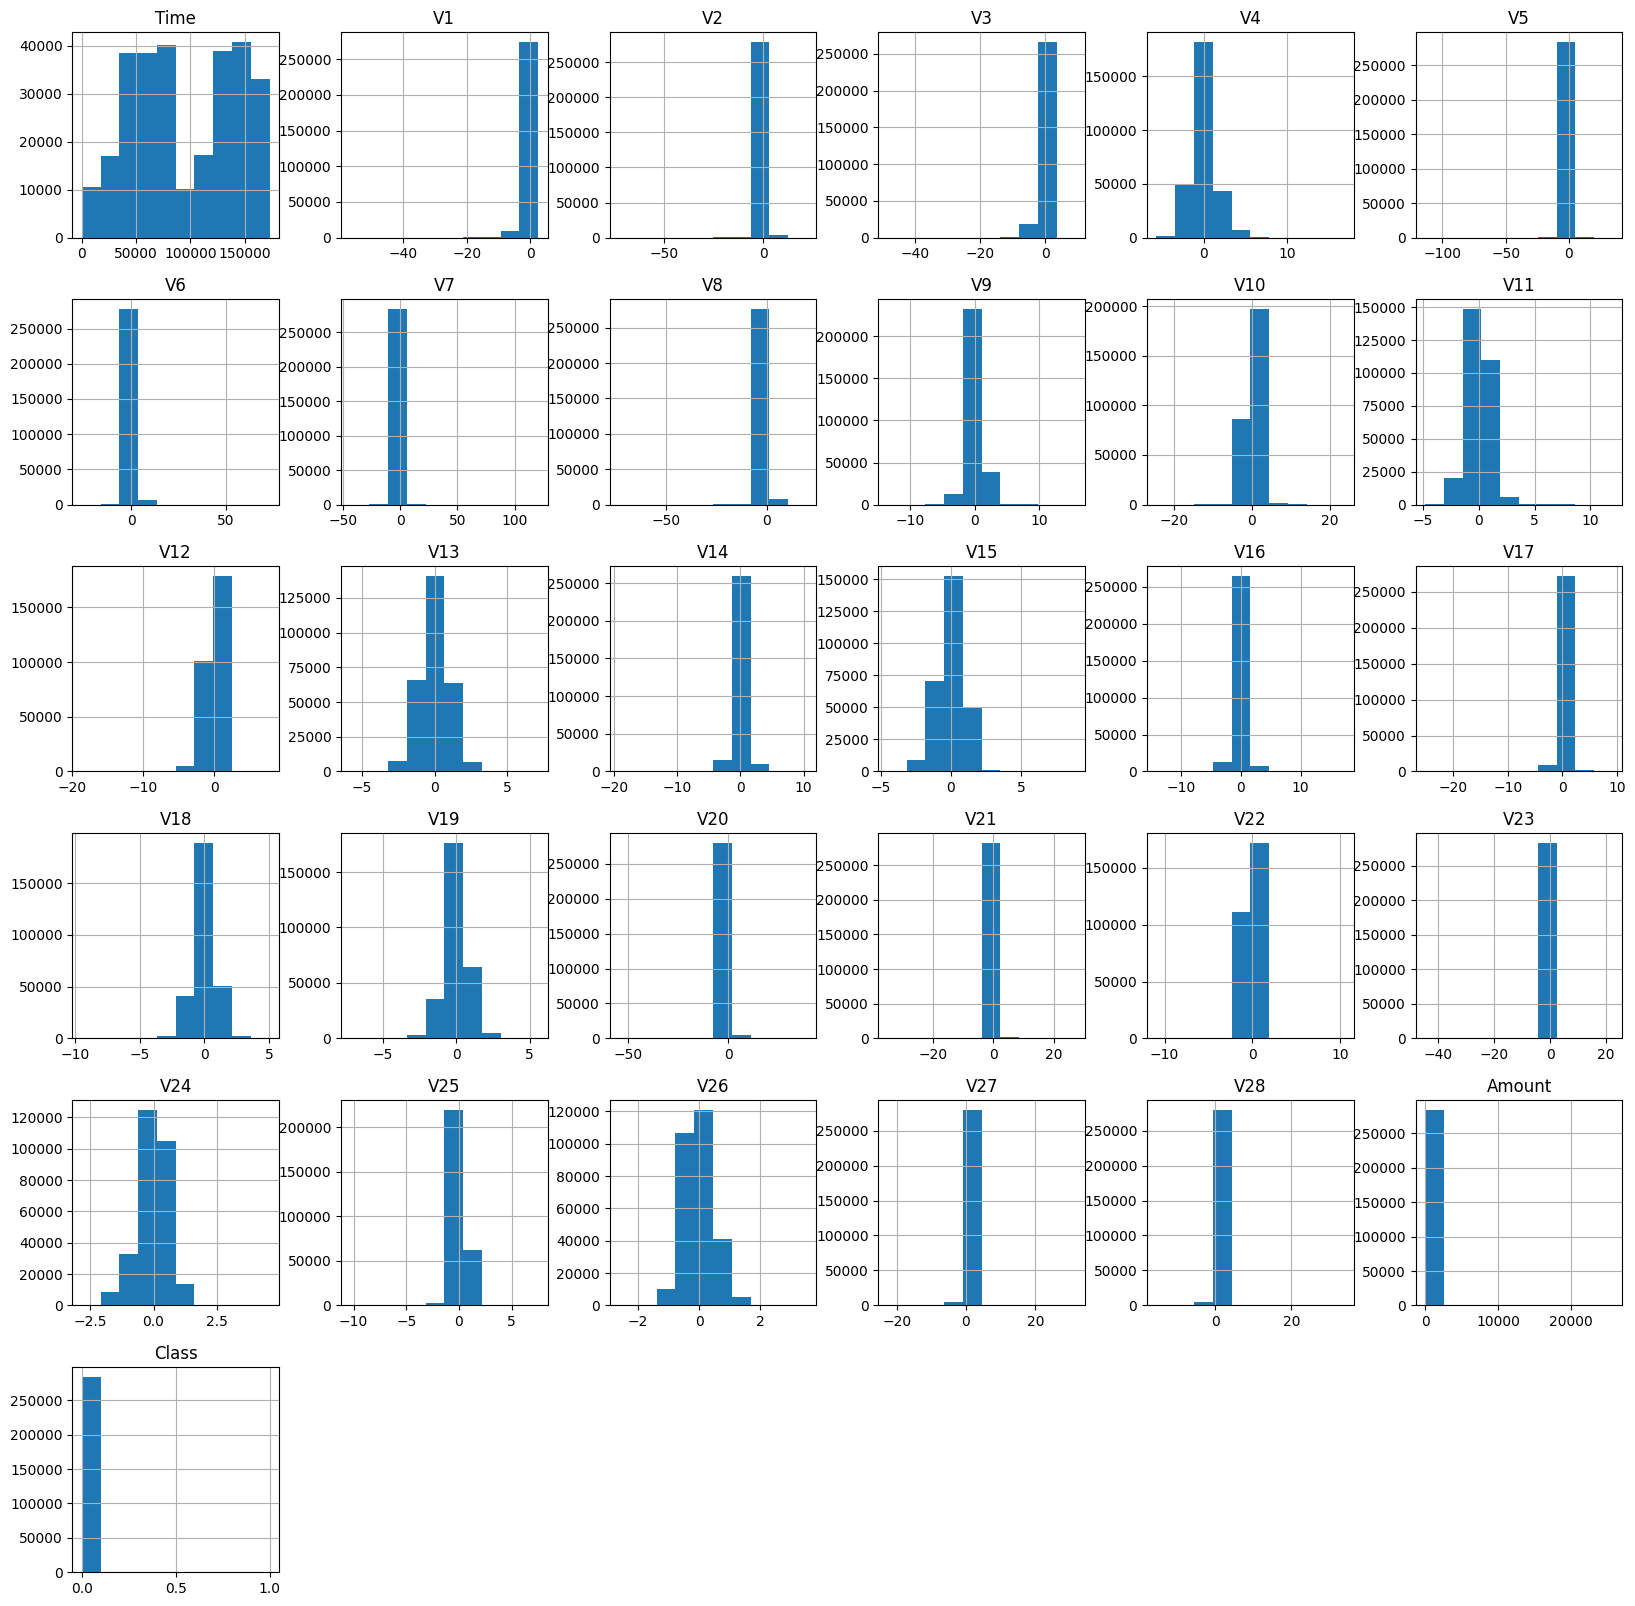

In [ ]:
#plot the histogram of each variable
cc_df.hist(figsize = (20,20))
plt.show()

In [ ]:
#What are the actual number for fraud and no fraud cases?
fraud = cc_df[cc_df['Class']==1]
no_fraud = cc_df[cc_df['Class']==0]
print('fraud cases are:', len(fraud))
print('no fraud cases are:', len(no_fraud))
print('percentage of fraud cases are:', round(len(fraud)/len(cc_df)*100,2),'%')
print('percentage of no fraud cases are:', round(len(no_fraud)/len(cc_df)*100,2),'%')

fraud cases are: 492
no fraud cases are: 284315
percentage of fraud cases are: 0.17 %
percentage of no fraud cases are: 99.83 %


In [ ]:
#What is happening is that, the timing between transactions are not statistically different
#but since we want to run a non liner model, we need to keep it as it is. Secondly, we can see
#lots of outliers present specifically in amount section hence, we need to do some pre processing
#for amount before running our desired model. In this case, I am taking a log of amount to
#reduce the skewness of variance

In [ ]:
#data preprocessing for amount
cc_df['Amount_log'] = np.log1p(cc_df['Amount'])
cc_df[['Amount', 'Amount_log']].describe()

,Amount,Amount_log
count,284807.000000,284807.000000
mean,88.349619,3.152188
std,250.120109,1.656648
min,0.000000,0.000000
25%,5.600000,1.887070
50%,22.000000,3.135494
75%,77.165000,4.358822
max,25691.160000,10.153941


In [ ]:
#let's do a pca on our remaining variables.
# Amount_log and Time, we would try to make it on the scale of v1 to v28

In [ ]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
cc_df['scaled_time'] = scaler.fit_transform(cc_df['Time'].values.reshape(-1,1))
cc_df['scaled_amount_log'] = scaler.fit_transform(cc_df['Amount_log'].values.reshape(-1,1))
cc_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V24,V25,V26,V27,V28,Amount,Class,Amount_log,scaled_time,scaled_amount_log
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,5.014760,-0.994983,0.760297
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,1.305626,-0.994983,-0.740312
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,5.939276,-0.994972,1.134330
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,4.824306,-0.994972,0.683245
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,4.262539,-0.994960,0.455970


In [ ]:
#our data is ready, let's drop the columns not required
cc_df.drop(['Time', 'Amount', 'Amount_log'], axis=1, inplace=True)
cc_df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_time,scaled_amount_log
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,-0.994983,0.760297
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.994983,-0.740312
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,-0.994972,1.134330
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,-0.994972,0.683245
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.994960,0.455970


In [ ]:
#describe
cc_df.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_time,scaled_amount_log
count,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000,284807.000000
mean,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,2.239053e-15,...,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,0.001727,0.118914,0.006754
std,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,...,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,0.041527,0.557903,0.670232
min,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,...,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,-0.994983,-1.268531
25%,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,...,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,0.000000,-0.358210,-0.505077
50%,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,...,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,0.000000,0.000000,0.000000
75%,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,...,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,0.000000,0.641790,0.494923
max,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,...,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,1.000000,1.035022,2.839462


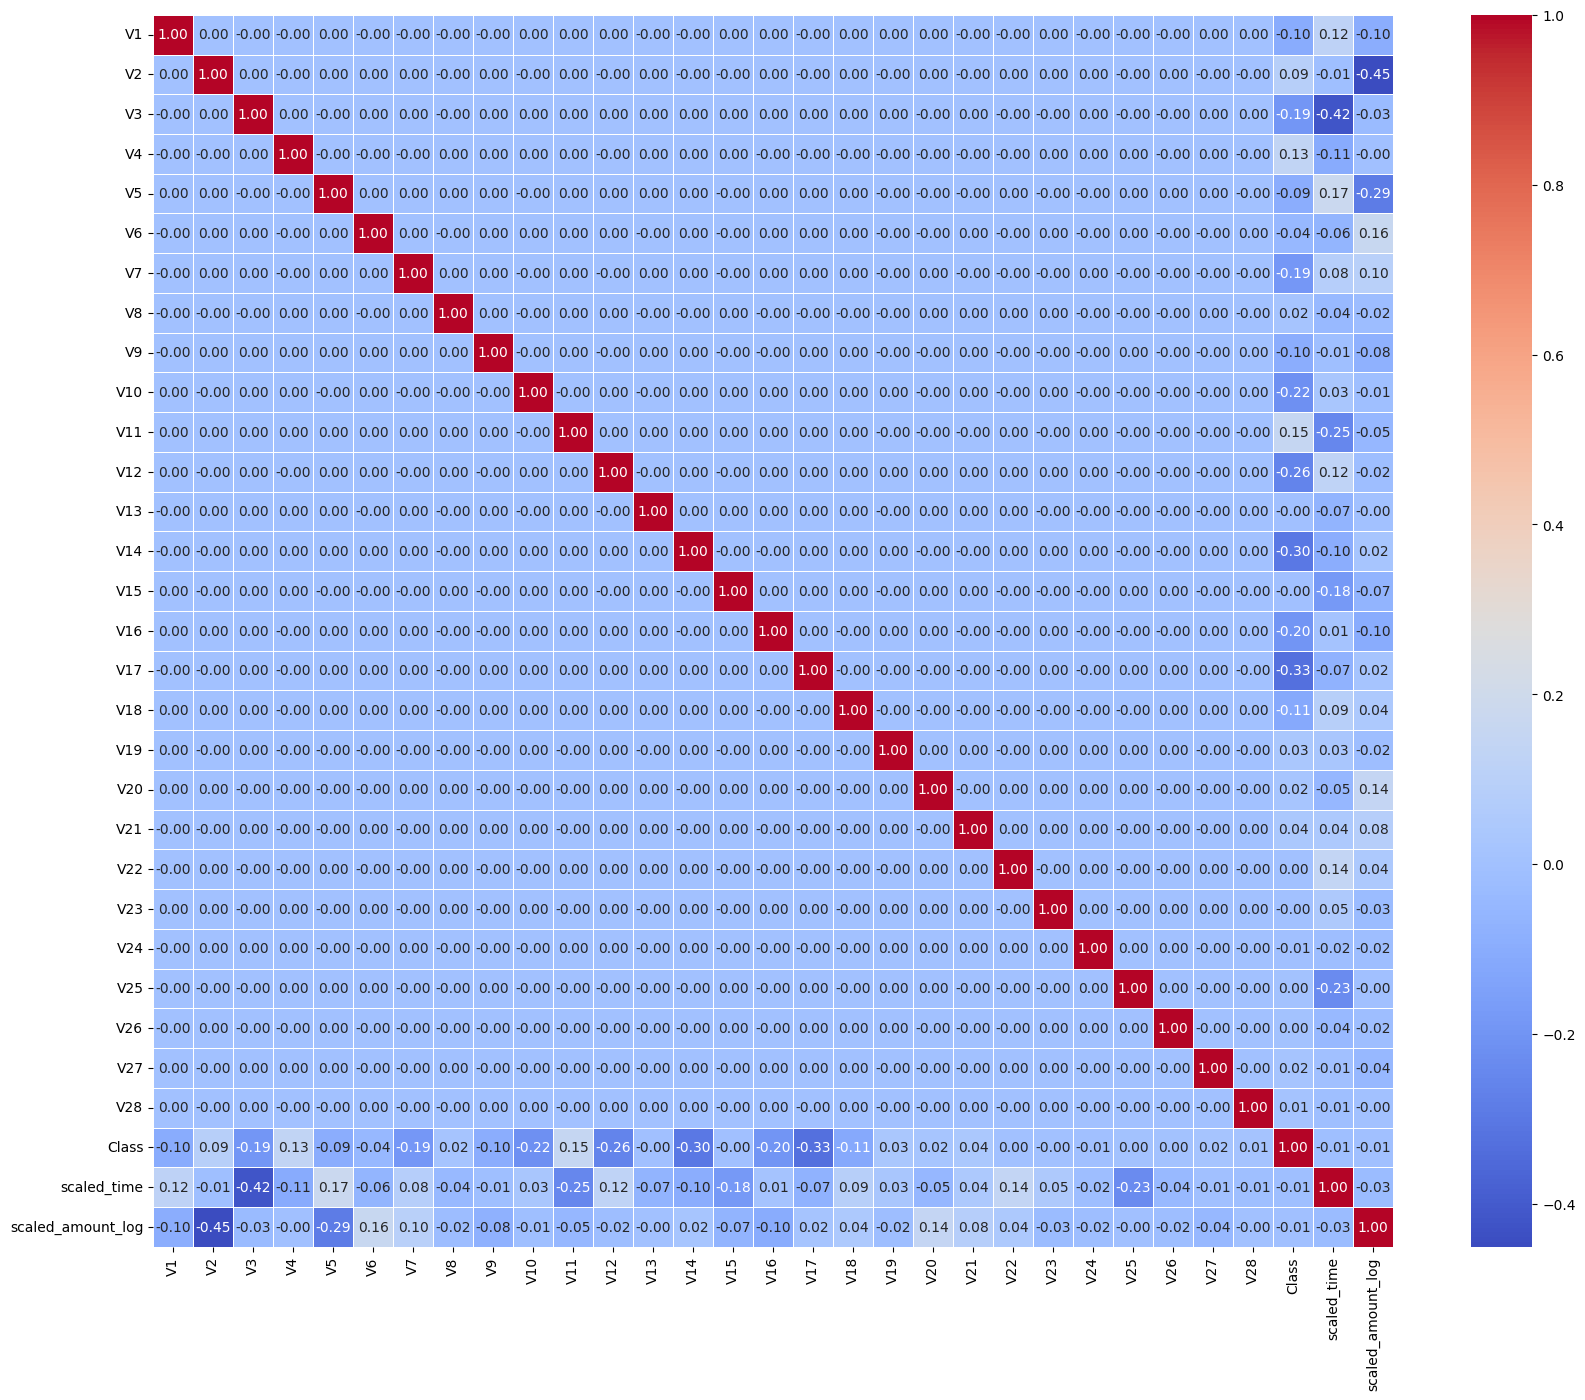

In [ ]:
#correalation between features
plt.figure(figsize = (20,16))
sns.heatmap(cc_df.corr(), annot=True, fmt = '.2f', cmap ='coolwarm', linewidth = '0.5')
plt.show()

In [ ]:
#Most of the variables are fairly non related as seen by the lighter color. Close to 0.

In [ ]:
cc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   V1                 284807 non-null  float64
 1   V2                 284807 non-null  float64
 2   V3                 284807 non-null  float64
 3   V4                 284807 non-null  float64
 4   V5                 284807 non-null  float64
 5   V6                 284807 non-null  float64
 6   V7                 284807 non-null  float64
 7   V8                 284807 non-null  float64
 8   V9                 284807 non-null  float64
 9   V10                284807 non-null  float64
 10  V11                284807 non-null  float64
 11  V12                284807 non-null  float64
 12  V13                284807 non-null  float64
 13  V14                284807 non-null  float64
 14  V15                284807 non-null  float64
 15  V16                284807 non-null  float64
 16  V1

In [ ]:
# cc_df['Class'] = cc_df['Class'].astype('str')
# cc_df.info()

In [ ]:
#Let's start running the model
from sklearn.model_selection import train_test_split
X = cc_df.drop('Class', axis=1)
Y = cc_df['Class']

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print("train size X : ",X_train.shape)
print("train size y : ",Y_train.shape)
print("test size X : ",X_test.shape)
print("test size y : ",Y_test.shape)

train size X :  (227845, 30)
train size y :  (227845,)
test size X :  (56962, 30)
test size y :  (56962,)


In [ ]:
Y_train.value_counts(normalize = True)

,proportion
Class,
0,0.998271
1,0.001729


In [ ]:
from sklearn.linear_model import LogisticRegression
lr_basemodel =LogisticRegression()
lr_basemodel.fit(X_train, Y_train)

LogisticRegression()

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, auc
from sklearn.metrics import roc_curve

[[56853    11]
 [   40    58]]


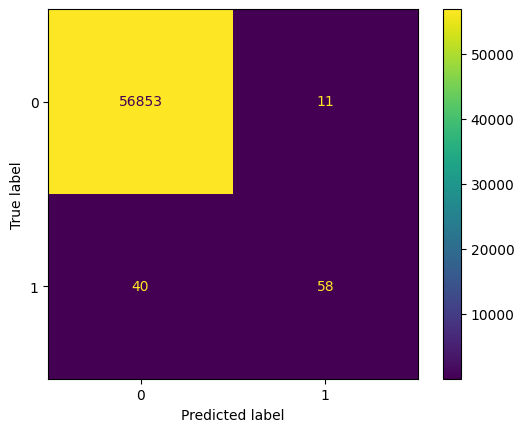

In [ ]:
Y_pred_test = lr_basemodel.predict(X_test)
ConfusionMatrix = confusion_matrix(Y_test, Y_pred_test)
print(ConfusionMatrix)
disp = ConfusionMatrixDisplay(confusion_matrix=ConfusionMatrix, display_labels=lr_basemodel.classes_)
disp.plot()
plt.show()

In [ ]:
 #Accuracy score
print("Accuracy score  test dataset: ", accuracy_score(Y_test,Y_pred_test))
#Precision score
print("precision score  test dataset: ", precision_score(Y_test,Y_pred_test))
#Recall Score
print("Recall score  test dataset: ", recall_score(Y_test,Y_pred_test))

Accuracy score  test dataset:  0.9991046662687406
precision score  test dataset:  0.8405797101449275
Recall score  test dataset:  0.5918367346938775


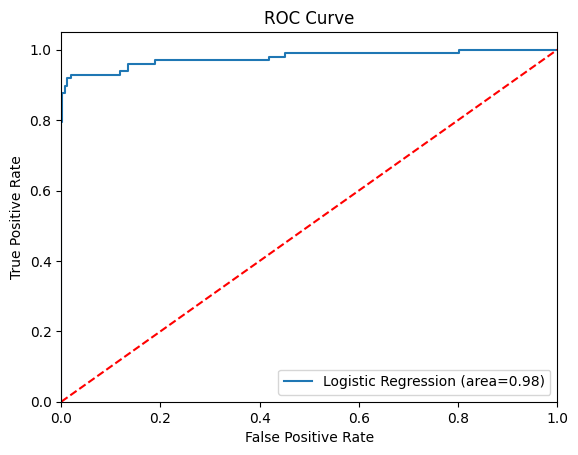

In [ ]:
fpr, tpr, thresholds = roc_curve(Y_test, lr_basemodel.predict_proba(X_test)[:,1])
auc_var=auc(fpr, tpr)

plt.figure()
plt.plot(fpr,tpr,label='Logistic Regression (area=%0.2f)' % auc_var)
plt.plot([0,1],[0,1],'r--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

In [ ]:
#This was intentional. On paper it all looks good, accuracy is 99%, AUC is large
#Now, we already know from our recall score, that the model is flagging high number of
#fraud transactions as genuine transaction because the dataset is essentially biased towards
#genuine transactions. So, let's try adding weights

In [ ]:
from sklearn.linear_model import LogisticRegression
lr_basemodel2 =LogisticRegression(class_weight='balanced')
lr_basemodel2.fit(X_train, Y_train)

LogisticRegression(class_weight='balanced')

[[55519  1345]
 [    8    90]]


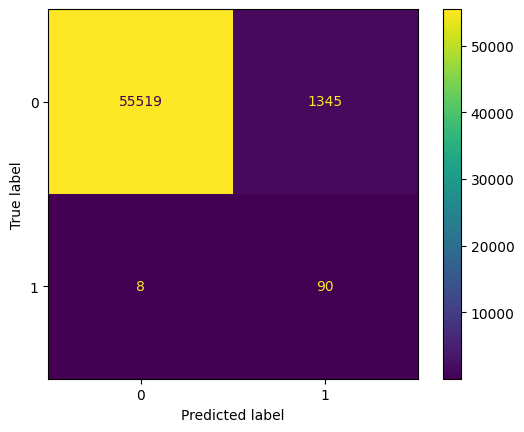

In [ ]:
Y_pred_test2 = lr_basemodel2.predict(X_test)
ConfusionMatrix2 = confusion_matrix(Y_test, Y_pred_test2)
print(ConfusionMatrix2)
disp = ConfusionMatrixDisplay(confusion_matrix=ConfusionMatrix2, display_labels=lr_basemodel2.classes_)
disp.plot()
plt.show()

In [ ]:
 #Accuracy score
print("Accuracy score  test dataset: ", accuracy_score(Y_test,Y_pred_test2))
#Precision score
print("precision score  test dataset: ", precision_score(Y_test,Y_pred_test2))
#Recall Score
print("Recall score  test dataset: ", recall_score(Y_test,Y_pred_test2))

Accuracy score  test dataset:  0.9762473227765879
precision score  test dataset:  0.0627177700348432
Recall score  test dataset:  0.9183673469387755


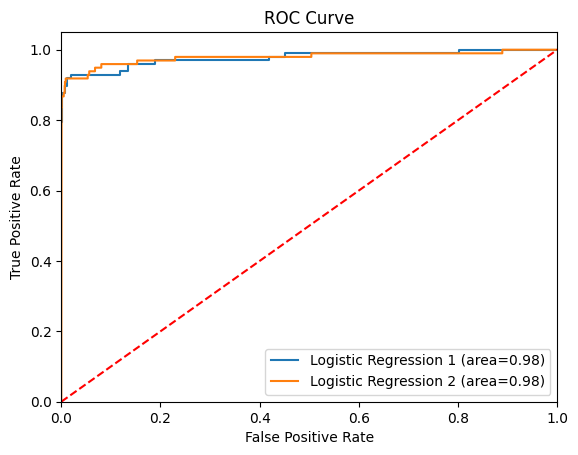

In [ ]:
fpr2, tpr2, thresholds2 = roc_curve(Y_test, lr_basemodel2.predict_proba(X_test)[:,1])
auc_var2=auc(fpr2, tpr2)

plt.figure()
plt.plot(fpr,tpr,label='Logistic Regression 1 (area=%0.2f)' % auc_var)
plt.plot(fpr2,tpr2,label='Logistic Regression 2 (area=%0.2f)' % auc_var2)
plt.plot([0,1],[0,1],'r--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

In [ ]:
#well, look at that. ALthough ROC didn't change much, our precision has dropped significantly
#our recall has improved by a lot. Improving recall is necessary as it tells that out of all
#the actual fraudelent transaction 91% were predicted correctly by our model, the number was 59%
#before. However, downside is that the model is saying out of all the predicted transactions
# labelled as fraud, only 6% were actually fraud. So, we are not missing any frauds
#but we are flagging too many genuine txns as fraudulent. So, let's change our weights a bit.

In [ ]:
from sklearn.linear_model import LogisticRegression
lr_basemodel3 =LogisticRegression(class_weight={0:1, 1:30})
lr_basemodel3.fit(X_train, Y_train)

LogisticRegression(class_weight={0: 1, 1: 30})

[[56814    50]
 [   15    83]]


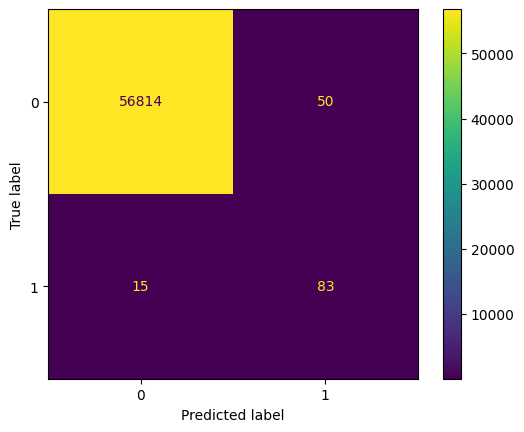

In [ ]:
Y_pred_test3 = lr_basemodel3.predict(X_test)
ConfusionMatrix3 = confusion_matrix(Y_test, Y_pred_test3)
print(ConfusionMatrix3)
disp = ConfusionMatrixDisplay(confusion_matrix=ConfusionMatrix3, display_labels=lr_basemodel3.classes_)
disp.plot()
plt.show()

In [ ]:
 #Accuracy score
print("Accuracy score  test dataset: ", accuracy_score(Y_test,Y_pred_test3))
#Precision score
print("precision score  test dataset: ", precision_score(Y_test,Y_pred_test3))
#Recall Score
print("Recall score  test dataset: ", recall_score(Y_test,Y_pred_test3))

Accuracy score  test dataset:  0.9988588883817282
precision score  test dataset:  0.6240601503759399
Recall score  test dataset:  0.8469387755102041


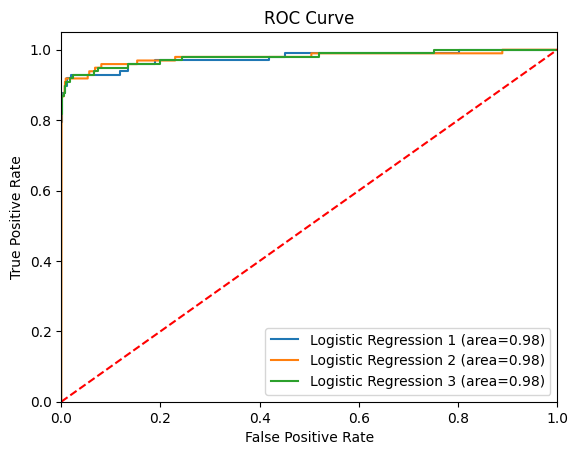

In [ ]:
fpr3, tpr3, thresholds = roc_curve(Y_test, lr_basemodel3.predict_proba(X_test)[:,1])
auc_var3=auc(fpr3, tpr3)

plt.figure()
plt.plot(fpr,tpr,label='Logistic Regression 1 (area=%0.2f)' % auc_var)
plt.plot(fpr2,tpr2,label='Logistic Regression 2 (area=%0.2f)' % auc_var2)
plt.plot(fpr3,tpr3,label='Logistic Regression 3 (area=%0.2f)' % auc_var3)
plt.plot([0,1],[0,1],'r--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

In [ ]:
#While keeping weights 1:1, we got a good accuracy but our recall score suffered,but
#when we balanced it (approx 1:500), we reduced accuracy slightly, to gain a massive jump in recall
#but with an absymal precision. This meant many genuine transactions could be flagged as fraud
#unnecessarily. Finally, through bracketing, we managed to find a balanced spot with 1:30 ratio
#We have managed to raise the precision from 6% to 64%, meaning we could correctly predict 64
#out of 100 predicted fraudelent transactions with just a slight decrease in recall from 91% to 84%